# 08.3 · LAB, YCrCb and robust thresholds

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain lab, ycrcb and robust thresholds using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[03 · Image Fundamentals](../../03-image-fundamentals/README.md), [04 · OpenCV Fundamentals](../../04-opencv-fundamentals/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

A color space is a coordinate system for color. RGB is convenient for displays, HSV separates hue from saturation and value, and LAB separates lightness from opponent color axes. Choosing a space can make a simple threshold useful, but it does not remove lighting variation.

## 2. Intuition

LAB lightness and chromatic coordinates can reduce some sensitivity to brightness, and YCrCb separates luma from chroma. Neither guarantees invariance to illumination or camera processing. Skin-color masks are especially fragile across people, lighting and devices; they should not be treated as identity detectors or universal human detectors.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 8
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
M=(h<h_1\;\lor\;h>h_2)\land(s>s_0)\land(v>v_0)
$$

M is a Boolean red mask, h hue, s saturation and v value. h1 and h2 bound the two sides of red; s0 and v0 reject gray and darkness. For h=178, s=200, v=150 and bounds 10,170,80,50, the mask is true.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
h, s, v = np.array([178, 30]), np.array([200, 200]), np.array([150, 150])
mask = ((h < 10) | (h > 170)) & (s > 80) & (v > 50)
assert mask.tolist() == [True, False]
print(mask)

[ True False]


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

Convert RGB to HSV once, threshold channels, combine hue intervals and clean the binary mask using morphology. A centroid can then drive a simple color tracker.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def colors(lesson, seed, amount):
    image = picture(seed)
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    mask = cv2.inRange(
        hsv,
        np.array([0, 100, 70], np.uint8),
        np.array([min(25, int(10 * amount)), 255, 255], np.uint8),
    )
    mask |= cv2.inRange(
        hsv, np.array([170, 100, 70], np.uint8), np.array([179, 255, 255], np.uint8)
    )
    space = cv2.cvtColor(image, cv2.COLOR_RGB2LAB if lesson == 1 else cv2.COLOR_RGB2YCrCb)
    return Result(
        "08 · Color spaces and red hue wraparound",
        {
            "RGB": image,
            "Hue (OpenCV 0–179)": hsv[..., 0],
            "Mask": mask,
            "Isolated object": np.where(mask[..., None] > 0, image, 0),
            "LAB or YCrCb first channel": space[..., 0],
        },
        metrics={"selected_fraction": float((mask > 0).mean())},
        notes="HSV thresholds depend on lighting. Color alone is not a reliable skin or identity classifier.",
    )

{
  "selected_fraction": 0.2686631944444444
}
HSV thresholds depend on lighting. Color alone is not a reliable skin or identity classifier.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import components

display(Code(inspect.getsource(components), language="python"))

def components(mask):
    """4-connected foreground labels using a queue flood-fill, background=0."""
    mask = np.asarray(mask, bool)
    labels = np.zeros(mask.shape, np.int32)
    count = 0
    for y, x in zip(*np.nonzero(mask), strict=True):
        if labels[y, x]:
            continue
        count += 1
        labels[y, x] = count
        queue = deque([(y, x)])
        while queue:
            yy, xx = queue.popleft()
            for dy, dx in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                yn, xn = yy + dy, xx + dx
                if 0 <= yn < mask.shape[0] and 0 <= xn < mask.shape[1]:
                    if mask[yn, xn] and not labels[yn, xn]:
                        labels[yn, xn] = count
                        queue.append((yn, xn))
    return labels, count

## 8. Experiment

Lower saturation while keeping hue fixed and observe the reliability of the red mask. Test two illuminations with the same object.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "selected_fraction": 0.2686631944444444
  },
  "second_seed": {
    "selected_fraction": 0.2690972222222222
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

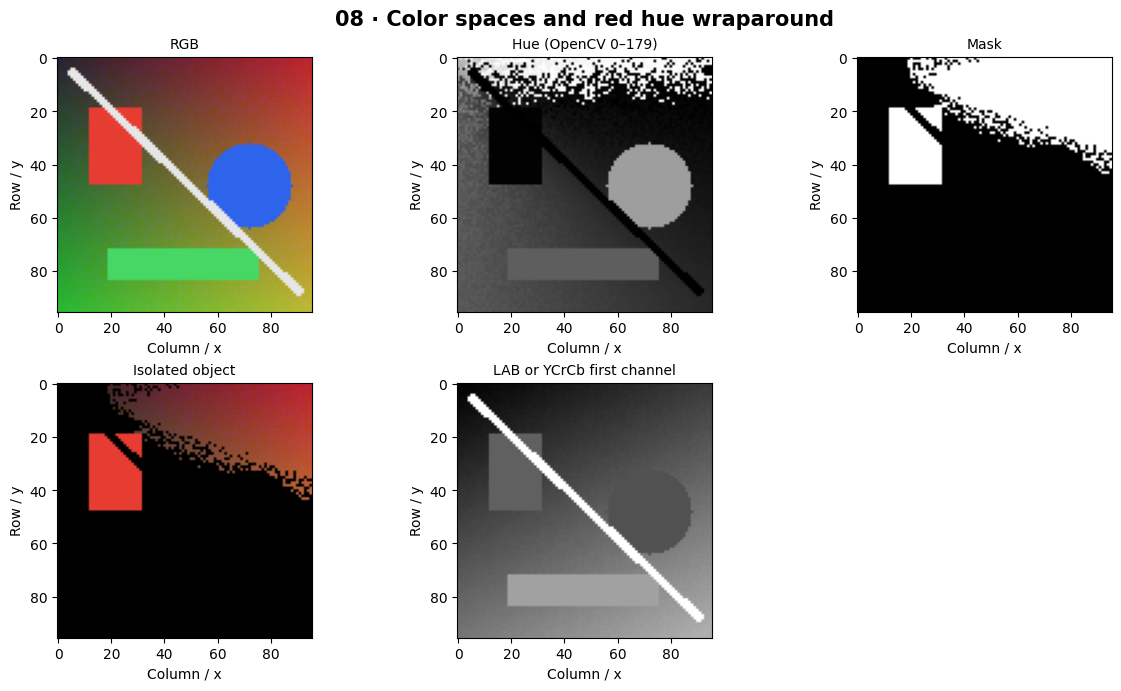

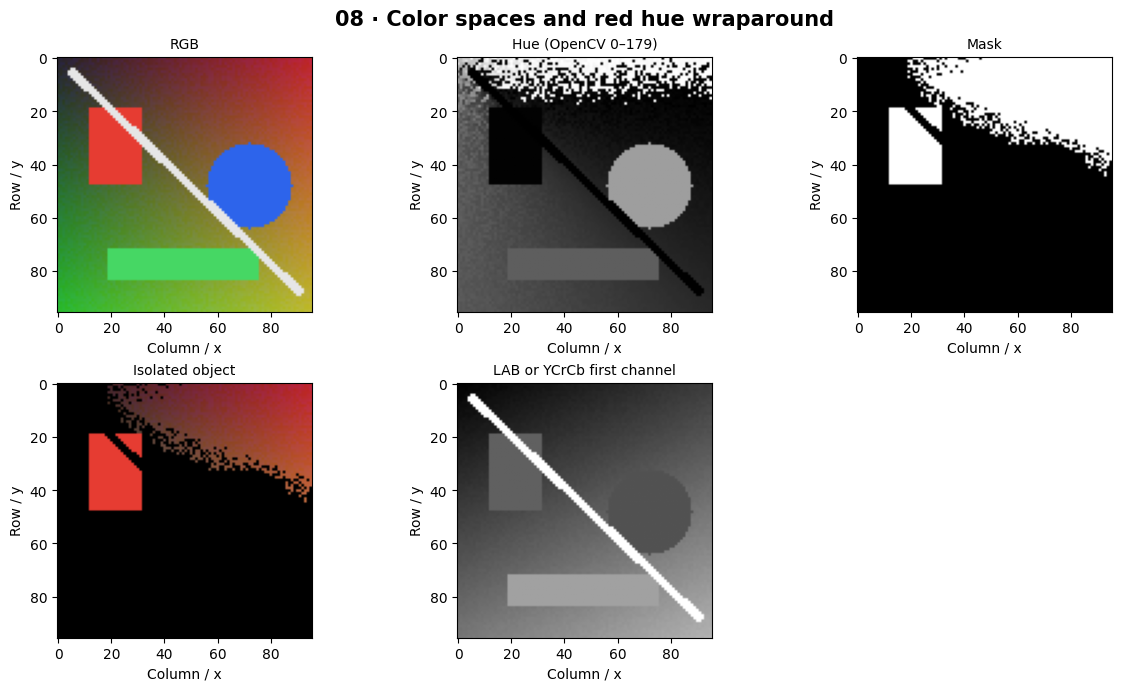

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Color Object Tracker**. Isolate a colored object while testing illumination changes. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Using hue degrees 0–360 directly on OpenCV uint8 HSV produces incorrect thresholds. Skin color is not a reliable substitute for a trained hand detector.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Lower saturation while keeping hue fixed and observe the reliability of the red mask. Test two illuminations with the same object.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Track a colored ball through changing brightness, log lost detections and provide a calibration control for the color interval.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

LAB lightness and chromatic coordinates can reduce some sensitivity to brightness, and YCrCb separates luma from chroma. Neither guarantees invariance to illumination or camera processing. Skin-color masks are especially fragile across people, lighting and devices; they should not be treated as identity detectors or universal human detectors.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[09 · Feature Detection](../../09-feature-detection/README.md)

[Primary reference](https://docs.opencv.org/4.x/df/d9d/tutorial_py_colorspaces.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)